## **Task 1: Data Loading and Initial Exploration**  # 

### **1.1 Loading Dataset** ##

In [115]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
df = pd.read_excel(r"D:\交流交换\MLF\assignment_1\titanic3.xls")

### **1.2 Explore Data Structure** ###

#### **1.2.1 Overview of first 5 rows** ###

In [117]:
print(df.head())

   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

       age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.0000      0      0   24160  211.3375       B5        S    2    NaN   
1   0.9167      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.0000      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  
0                     St 

#### **1.2.2 Feature types** ###

In [118]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB
None


### **Key Observations:**

- There are a total of **1309 entries (people)** and **14 columns (features)** recorded in the Titanic Dataset.

- **Feature types**:
    - **Integers (4)**: `pclass`, `survived`, `sibsp`, `parch`
    - **Floats (3)**: `age`, `fare`, `body`
    - **Object (7)**: `neme`, `sex`, `ticket`, `cabin`, `embarked`, `boat`, `home.dest`

#### **1.2.3 Explore missing values** ###

In [119]:
print(df.isnull().sum())

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64


Plot number of missing values by features.

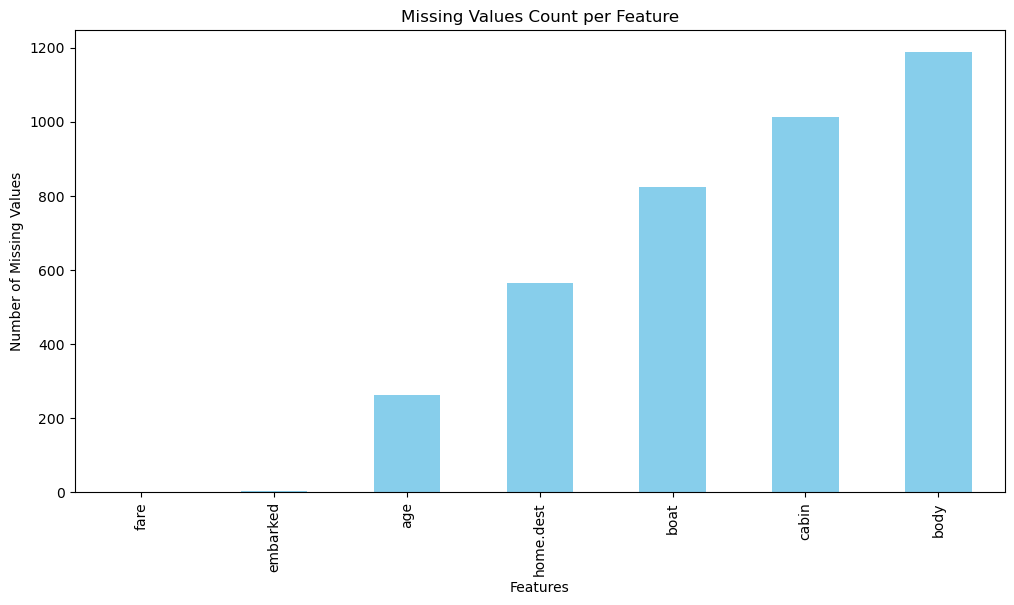

In [120]:
# Count the number of missing values of features
missing_data = df.isnull().sum()

plt.figure(figsize=(12, 6))
missing_data[missing_data > 0].sort_values().plot(kind='bar', color='skyblue')

plt.title('Missing Values Count per Feature')
plt.xlabel('Features')
plt.ylabel('Number of Missing Values')

plt.show()

- The dataset has missing values in **age, cabin, embarked, boat, body, and home.dest.**

#### **Missing Data Analysis**

1. **`body`**:  
   Missing for most non-surviving passengers (**1188 entries**), indicating that the bodies of those who did not survive were not recovered or documented.

2. **`cabin`**:  
   Large number of missing values (**1014**) suggests many passengers did not have their cabin information recorded, possibly due to incomplete documentation or non-cabin passengers.

3. **`boat`**:  
   Many missing values (**823**) because only survivors have lifeboat data, so non-survivors naturally have missing entries for this feature.

4. **`home.dest`**:  
   A considerable number of missing values (**564**) likely due to incomplete passenger registration. Not all passengers may have had their final destination recorded, especially if it wasn’t relevant to boarding.


### **1.3 Features Statistics** ###

In [121]:
print(df.describe(include='all'))

             pclass     survived                  name   sex          age  \
count   1309.000000  1309.000000                  1309  1309  1046.000000   
unique          NaN          NaN                  1307     2          NaN   
top             NaN          NaN  Connolly, Miss. Kate  male          NaN   
freq            NaN          NaN                     2   843          NaN   
mean       2.294882     0.381971                   NaN   NaN    29.881135   
std        0.837836     0.486055                   NaN   NaN    14.413500   
min        1.000000     0.000000                   NaN   NaN     0.166700   
25%        2.000000     0.000000                   NaN   NaN    21.000000   
50%        3.000000     0.000000                   NaN   NaN    28.000000   
75%        3.000000     1.000000                   NaN   NaN    39.000000   
max        3.000000     1.000000                   NaN   NaN    80.000000   

              sibsp        parch    ticket         fare        cabin embark

In [122]:
# 查看每类频数
pclass_counts = df['sex'].value_counts()

# 查看每类占比
pclass_percentages = df['sex'].value_counts(normalize=True) * 100

print("Pclass Counts:")
print(pclass_counts)
print("\nPclass Percentages (%):")
print(pclass_percentages)


Pclass Counts:
sex
male      843
female    466
Name: count, dtype: int64

Pclass Percentages (%):
sex
male      64.400306
female    35.599694
Name: proportion, dtype: float64


#### **Key Statistics:**

- **Survival Rate**: **38.4%** survived (mean = 0.384).

- **Class Distribution**:
    - **24.7%** in 1st class
    - **21.2%** in 2nd class
    - **54.2%** in 3rd class

- **Age**:
    - **Mean age** ≈ **29.9 years**
    - **Large span**: From **0.17 years** (infant) to **80 years** (elderly)




#### **Feature Summary**

1. **`pclass`**: Mean: 2.29. Most passengers were distributed in 2nd and 3rd class.
2. **`survived`**: Indicates survival status, with 38% of passengers surviving.
3. **`sex`**: 64% being male.
4. **`age`**: A mean of 29.88 years. 263 missing values (20% of the data)
5. **`sibsp`**: Range from 0-8. Mean: 0.50, suggesting that most passengers traveled alone or with only one sibling/spouse.
7. **`parch`**: Range from 0-9. Mean: 0.39, indicating most passengers traveled without parents or children.
9. **`fare`**: Range from 0 to 512.33. Std of 51.76, suggesting a wide range of fare prices (outliers).


### **1.4 Exploration and Visulization of Key Features** ###

#### **1.4.1 Survival Rate by Gender** ###

In [123]:
gender_survival = df.groupby('sex')['survived'].mean()
print("Sex survival rate:\n", gender_survival)

Sex survival rate:
 sex
female    0.727468
male      0.190985
Name: survived, dtype: float64


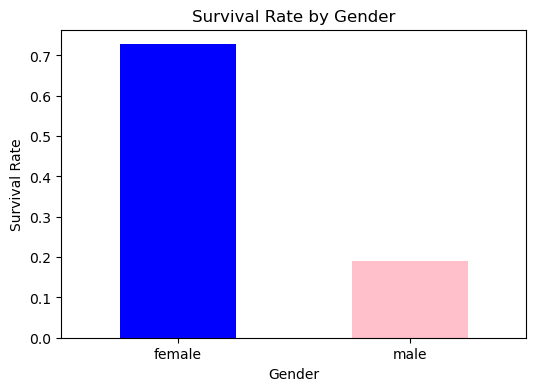

In [124]:
plt.figure(figsize=(6, 4))
gender_survival.plot(kind='bar', color=['blue', 'pink'])

plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)  

plt.show()

Based on the survival rate data for each gender, we can make the following observations:

- **Female passengers** have a significantly **higher survival rate** of **72.7%**, compared to **19.1%** for **male passengers**.
- This disparity in survival rates can be attributed to various factors, including **gender-based prioritization** in the rescue efforts, where women and children were typically given priority during evacuation.

#### **1.4.2 Survival Rate by class** ###

In [125]:
# Calculate survival rate by passenger class
survival_by_class = df.groupby('pclass')['survived'].mean()

# Display the results
print("Survival Rate by Passenger Class:")
print(survival_by_class)

Survival Rate by Passenger Class:
pclass
1    0.619195
2    0.429603
3    0.255289
Name: survived, dtype: float64


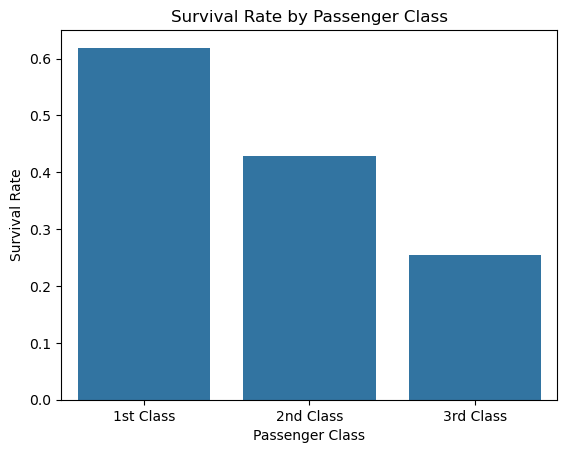

In [126]:
# Plot survival rate by passenger class
sns.barplot(x=survival_by_class.index, y=survival_by_class.values)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(ticks=[0, 1, 2], labels=['1st Class', '2nd Class', '3rd Class'])
plt.show()

It can be inferred that the **class of the cabin** largely determines the **survival chances** of the passengers.

- **First Class** and **Second Class** passengers have **higher chances** of being rescued, while those in the **lower-income third class** have a **lower survival rate**.
- This disparity might be due to **unequal social status** and the **lower cabin position** of third-class passengers, which potentially made it harder for them to access life-saving resources and escape.

## **Task 2: Data Splitting**

To avoid **data leakage**, we adjust the sequence of data processing. The dataset should be **split before handling missing values** to ensure that missing value **imputation is based solely on the training data**. The same imputation strategy is applied to the validation and test sets without recalculating statistics.

### **2.1 Remove Features Containing Future Information**

Before data splitting, features containing **future information** (before prediction time t) **must be removed** before any feature engineering or preprocessing to **prevent data leakage**.

We identified **two features** containing future information that must be removed first:
- **`boat`**: This field is only filled in when the passenger is rescued (i.e., after the predicted time t), and it **belongs to future data**.
- **`body`**: This field is only filled in when the passenger has not been rescued and the body has been found (i.e., after the predicted time t), and it **belongs to future data**.

In [127]:
# Drop future information features
df = df.drop(columns=['boat', 'body'])

### **2.2 Splitting Strategy**

- The dataset contains 1309 samples. We use **70-15-15** for splitting **as** the training, validation and test set sample sizes are all **sufficient** for modeling and evaluation of **medium-size datasets**.
- Use **stratified sampling** to ensure that the category proportions of the **target variable** (survived) are consistent.
- We also use the **random_state parameter** to **control randomness**, ensuring the results can be replicated.

As `name` is a unique identifier and is irrelevant to the prediction target, we **remove irrelevant features** before splitting the dataset.

In [128]:
from sklearn.model_selection import train_test_split

# 'survived' as the target variable
X = df.drop(['survived', 'name'], axis=1)
y = df['survived']

# First split the dataset into training and 'others'
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Split 'others' into equally sized validation and test sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Concatenate X_train and y_train for processing convenience
train_data = pd.concat([X_train, y_train], axis=1)

## **Task 3: Managing Missing Values**

### **3.1 Identifying Columns with Missing Values**
The analysis in part 1 has identified and **ranked** the following features with missing values:

**Under 5%**:
- **`fare`**: 1 missing value (<1%)
- **`embarked`**: 2 missing values (<1%)

**Over 20%**:
- **`age`**: 263 missing values (20%)
- **`home.dest`**: 564 missing values (43%)
- **`cabin`**: 1014 missing values (78%)

#### In the following section, we will handle the missing values by mainly focusing in **three aspects**: 

- **Feature type**
- **Percentage of missing values**
- **Feature statistics**.

### **3.2 Handle Missing Values** ###

After splitting the dataset, we **process the training set first**, and then fill the validation set and test set based on the **statistical values of the training set** to prevent **data leakage and ensure the fairness of the assessment**.


##### **3.2.1 `Fare` (<1%)** 

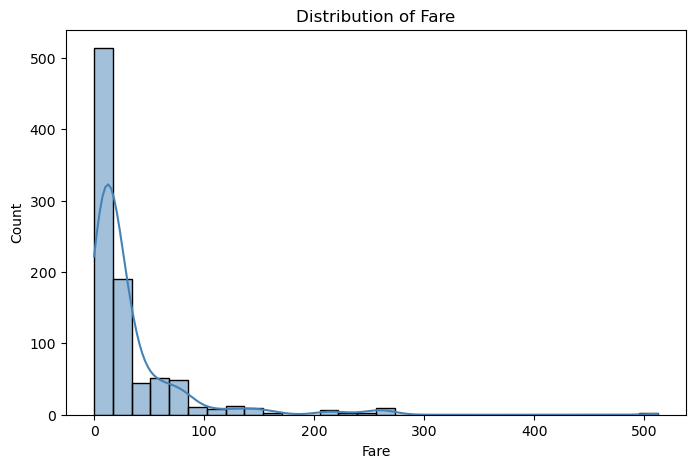

In [129]:
plt.figure(figsize=(8, 5))
sns.histplot(train_data['fare'].dropna(), bins=30, kde=True, color='steelblue')
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

The distribution of Fare is **heavily right skewed**, thus we use the **median** instead of mean to fill missing value.

In [130]:
# Impute missing values in fare with the median (based on training data)
fare_median = train_data['fare'].median()
X_train['fare'] = X_train['fare'].fillna(fare_median)
X_val['fare'] = X_val['fare'].fillna(fare_median)
X_test['fare'] = X_test['fare'].fillna(fare_median)

In [131]:
for dataset, name in zip([X_train, X_val, X_test], ['Train', 'Validation', 'Test']):
    print(f"Missing 'fare' in {name} set: {dataset['fare'].isnull().sum()}")

Missing 'fare' in Train set: 0
Missing 'fare' in Validation set: 0
Missing 'fare' in Test set: 0


##### **3.2.2 `embarked` (<1%)** 

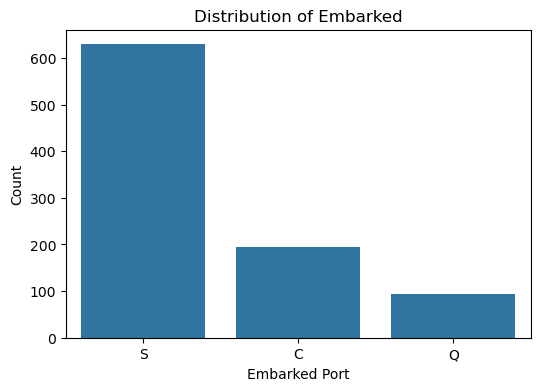

In [132]:
# Plot the distribution of embarked in the training data
plt.figure(figsize=(6, 4))
sns.countplot(x=train_data['embarked'], order=train_data['embarked'].value_counts().index)
plt.title("Distribution of Embarked")
plt.xlabel("Embarked Port")
plt.ylabel("Count")
plt.show()

Embarked is an object variable. It Shows an obvious mode (S being the most frequent) → directly **fill with the mode**.

In [133]:
# Impute missing values in embarked with the mode (based on training data)
embarked_mode = train_data['embarked'].mode().iloc[0]
X_train['embarked'] = X_train['embarked'].fillna(embarked_mode)
X_val['embarked'] = X_val['embarked'].fillna(embarked_mode)
X_test['embarked'] = X_test['embarked'].fillna(embarked_mode)

In [134]:
for dataset, name in zip([X_train, X_val, X_test], ['Train', 'Validation', 'Test']):
    print(f"Missing 'embarked' in {name} set: {dataset['embarked'].isnull().sum()}")

Missing 'embarked' in Train set: 0
Missing 'embarked' in Validation set: 0
Missing 'embarked' in Test set: 0


##### **3.2.3 `age` (20%)** 

Age is a continuous variable. The percentage of missing values is approximately 20%, which is a **relatively high**. 
Simply filling in with the global median would result in the **loss of the underlying patterns and distribution information** behind the missing values.

We plot **boxplot** to see whether age varies among different passenger class:

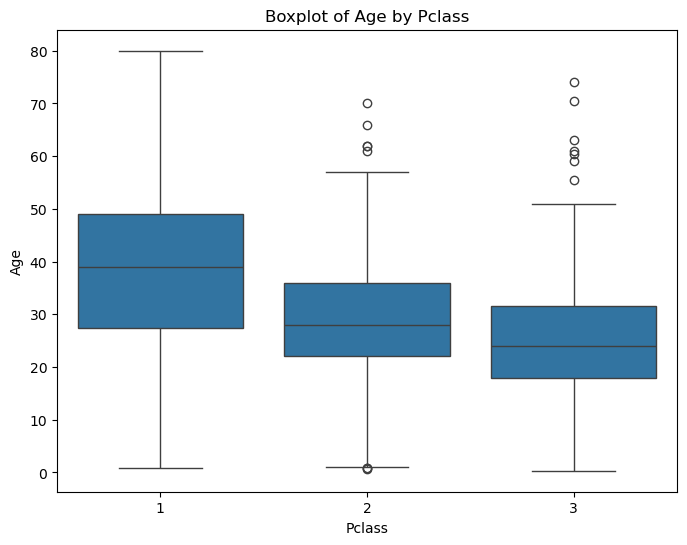

In [135]:
# Plot boxplot to see the age distribution by passenger class
plt.figure(figsize=(8, 6))
sns.boxplot(x='pclass', y='age', data=train_data)
plt.title('Boxplot of Age by Pclass')
plt.xlabel('Pclass')
plt.ylabel('Age')
plt.show()

The distribution of age varies across different passenger class, thus using **group filling** would be more appropriate

In [136]:
# Fill missing values in age using the median within each pclass group (based on training data)
X_train['age'] = X_train.groupby('pclass')['age'].transform(lambda x: x.fillna(x.median()))
for dataset in [X_val, X_test]:
    dataset['age'] = dataset.groupby('pclass')['age'].transform(
        lambda x: x.fillna(X_train.loc[X_train['pclass'] == x.name, 'age'].median())
    )

In [137]:
for dataset, name in zip([X_train, X_val, X_test], ['Train', 'Validation', 'Test']):
    print(f"Missing 'age' in {name} set: {dataset['age'].isnull().sum()}")

Missing 'age' in Train set: 0
Missing 'age' in Validation set: 0
Missing 'age' in Test set: 0


##### **3.2.4 `home.dest` (43%)** 

Home destination is an objective. It has more than **500 missing values**. Thus, we need to test **whether it significantly affects survival rate** or not, and decide to fill value or drop it. 

In [138]:
from scipy.stats import chi2_contingency

# Perform a chi-square test to evaluate its impact on survival (based on training data)
contingency_table = pd.crosstab(train_data['home.dest'].fillna("Unknown"), train_data['survived'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"P-value for Chi-square test: {p}")

if p > 0.05:
    print("home.dest does not significantly affect survival. It can be removed.")
else:
    print("home.dest significantly affects survival. Missing values will be filled with 'Unknown'.")

P-value for Chi-square test: 8.386653865144472e-05
home.dest significantly affects survival. Missing values will be filled with 'Unknown'.


As it isgnificantlly affect survival, we keep this feature. We **use "Unknown"(category label) to fill in the missing values**.

In [139]:
# Fill missing values in home.dest with "Unknown"
X_train['home.dest'] = X_train['home.dest'].fillna("Unknown")
X_val['home.dest'] = X_val['home.dest'].fillna("Unknown")
X_test['home.dest'] = X_test['home.dest'].fillna("Unknown")

In [140]:
for dataset, name in zip([X_train, X_val, X_test], ['Train', 'Validation', 'Test']):
    print(f"Missing 'home.dest' in {name} set: {dataset['home.dest'].isnull().sum()}")

Missing 'home.dest' in Train set: 0
Missing 'home.dest' in Validation set: 0
Missing 'home.dest' in Test set: 0


##### **3.2.5 cabin (78%)**

The vast majority of passengers did not record the cabin information. Thus, we consider **deleting cabin** as filling the missing value would bring a lot of uncertainty.

In [141]:
# Drop these features as the majority of data is missing, making imputation unreliable
X_train = X_train.drop(columns=['cabin'])
X_val = X_val.drop(columns=['cabin'])
X_test = X_test.drop(columns=['cabin'])
print(X_train.head())

      pclass   sex   age  sibsp  parch      ticket     fare embarked  \
306        1  male  54.0      0      1       35281  77.2875        S   
927        3  male  24.0      1      0        2660  14.4542        C   
642        3  male  13.0      4      2      347077  31.3875        S   
1294       3  male  28.5      0      0       54636  16.1000        S   
1015       3  male  55.5      0      0  A.5. 11206   8.0500        S   

                 home.dest  
306          Brunswick, ME  
927                Unknown  
642   Sweden Worcester, MA  
1294               Unknown  
1015               Unknown  


## **Task 4: Encoding Categorical Variables**  # 

### **4.1 Identifying Categorical Variables**

**Categorical Variables are as follow:**

1. **`pclass`**: The passenger class (1, 2, 3)
2. **`sex`**: Gender of the passenger (male, female)
3. **`embarked`**: The port of embarkation (C, Q, S)
4. **`home.dest`**: The home destination of the passenger (various locations)
5. **`ticket`**: Mixed Format. Contains numeric and text prefixes (e.g., "PC," "WE/P") 

We first check **whether** the categrical variables are **suitable** for OneHotEcoder.

In [142]:
# View the number of categories for each variable
categorical_columns = ['pclass', 'sex', 'embarked', 'home.dest', 'ticket']

for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

pclass: 3 unique values
sex: 2 unique values
embarked: 3 unique values
home.dest: 369 unique values
ticket: 939 unique values


The **number of categories** for **`home.dest` and `ticket`** are relatively large. Using OneHot encoding might **generate a large number of sparse matrices (high dimensions)**, making the model training inefficient. Thus, we use **frequency coding** for those features.

### **4.2 Encoding Strategy**

- To prevent data leakage, we **encode** the training set, validation set and test set **respectively**.
- The encoder is **fitted** based on the **training set**, and then **applied to** the validation set and the test set to ensure that the **encoding methods are consistent** and guarantee the fairness of model training and evaluation.

### **4.3 Apply OneHotEncoder & Frequency coding**

##### **4.3.1 OneHotEncoder** ###

We first apply **OneHotEncoder** to convert categorical variables into numerical formats for ML.

In [143]:
from sklearn.preprocessing import OneHotEncoder
# Specify categorical features for one-hot encoding
categorical_features = ['pclass', 'sex', 'embarked']

# Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Fit the encoder on the training set only
encoder.fit(X_train[categorical_features])

# Transform training, validation, and test sets
X_train_encoded = encoder.transform(X_train[categorical_features])
X_val_encoded = encoder.transform(X_val[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])

# Create encoded DataFrames with appropriate column names
encoded_columns = encoder.get_feature_names_out(categorical_features)
X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoded_columns, index=X_train.index)
X_val_encoded = pd.DataFrame(X_val_encoded, columns=encoded_columns, index=X_val.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=encoded_columns, index=X_test.index)

# Drop original categorical columns and join encoded data
X_train = X_train.drop(columns=categorical_features).join(X_train_encoded)
X_val = X_val.drop(columns=categorical_features).join(X_val_encoded)
X_test = X_test.drop(columns=categorical_features).join(X_test_encoded)


##### **4.3.2 Frequency coding** ###

Frequency coding for home.dest and ticket.

In [144]:
frequency_features = ['home.dest', 'ticket']
for feature in frequency_features:
    # Compute frequency from the training set only
    freq_map = X_train[feature].value_counts() / len(X_train)
    
    # Apply frequency coding to all datasets
    X_train[f"{feature}_freq"] = X_train[feature].map(freq_map)
    X_val[f"{feature}_freq"] = X_val[feature].map(freq_map).fillna(0)  # Fill NaN with 0 for unseen categories
    X_test[f"{feature}_freq"] = X_test[feature].map(freq_map).fillna(0)

# Drop the original 'boat' and 'home.dest' columns after encoding
X_train = X_train.drop(columns=frequency_features)
X_val = X_val.drop(columns=frequency_features)
X_test = X_test.drop(columns=frequency_features)

### **4.4 Observation of Transformation**

We take training set as an example.

In [145]:
X_train

,age,sibsp,parch,fare,pclass_2,pclass_3,sex_male,embarked_Q,embarked_S,home.dest_freq,ticket_freq
306,54.0,0,1,77.2875,0.0,0.0,1.0,0.0,1.0,0.002183,0.002183
927,24.0,1,0,14.4542,0.0,1.0,1.0,0.0,0.0,0.429039,0.002183
642,13.0,4,2,31.3875,0.0,1.0,1.0,0.0,1.0,0.003275,0.006550
1294,28.5,0,0,16.1000,0.0,1.0,1.0,0.0,1.0,0.429039,0.002183
1015,55.5,0,0,8.0500,0.0,1.0,1.0,0.0,1.0,0.429039,0.001092
...,...,...,...,...,...,...,...,...,...,...,...
577,31.0,0,0,21.0000,1.0,0.0,0.0,0.0,1.0,0.002183,0.002183
1080,24.0,0,0,7.7500,0.0,1.0,1.0,1.0,0.0,0.429039,0.001092
117,30.0,0,0,56.9292,0.0,0.0,0.0,0.0,0.0,0.429039,0.001092
759,36.0,1,0,17.4000,0.0,1.0,0.0,0.0,1.0,0.002183,0.002183


##### **4.4.1 Transformation of OneHotEncoder** ###

**Observation**: OneHotEncoder transforms categorical variables into **binary features (0.0 or 1.0)** for each category. It may generate new features. The new encoded variables are shown as follow:

- **`pclass`** was split into two binary columns: `pclass_2` and `pclass_3`, with `pclass_1` serving as the baseline category.
- **`sex`** was split into `sex_male`, where 1 indicates male and 0 indicates female.
- **`embarked`** was split into `embarked_Q` and `embarked_S`, with `embarked_C` as the reference category.

**Impact**: OneHotEncoder **transforms** categorical variables into **numerical variables** suitable for ML. It also **increases dimensionality**.

##### **4.4.2 Transformation of frequency coding** ###

**Observation**: Frequency Encoding replaces categorical variables with their **relative frequencies** in the training data.

- **`ticket_freq`**: Represents the proportion of passengers holding a specific ticket relative to the entire dataset.
- **`home.dest_freq`**: Represents the proportion of passengers associated with a specific home destination.

**Impact**: It can handle high cardinality and **preserve the original dataset dimensions**.

## **Task 5: Feature Scaling**  # 

### **5.1 Identifying Scaling Variables**

The numerical features that need scaling include:

- **`age`**: Continuous numerical variable.
- **`sibsp`**: Number of siblings/spouses aboard.
- **`parch`**: Number of parents/children aboard.
- **`fare`**: Continuous numerical variable.
- **`home.dest_freq`**
- **`ticket_freq`**

As for `pclass_2`, `pclass_3`, `sex_male`, `embarked_Q`, `embarked_S`, there is no need to standardize as these features are already binary values (0 or 1).

### **5.2 Scaling Strategy**

Our **goal** is to rain a **Logistic Regression Model** to predict whether a passenger survives, and the algorithm **assume normally distribution**. Standardization serves as a better option as it transforms the data to 0 mean and a standard deviation of 1 and preserves the original diatribution. 

In [146]:
from sklearn.preprocessing import StandardScaler
features_to_scale = ['age', 'sibsp', 'parch', 'fare', 'home.dest_freq', 'ticket_freq']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])

# Use the fit on the training set to transform the validation set and the test set
X_val_scaled = X_val.copy()
X_val_scaled[features_to_scale] = scaler.transform(X_val[features_to_scale])

X_test_scaled = X_test.copy()
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

In [147]:
X_train_scaled.columns

Index(['age', 'sibsp', 'parch', 'fare', 'pclass_2', 'pclass_3', 'sex_male',
       'embarked_Q', 'embarked_S', 'home.dest_freq', 'ticket_freq'],
      dtype='object')

## **Task 6: Addressing Class Imbalance**  # 

We first check whether the distribution of **dependent variable `survived`** is balanced.

In [148]:
y_train.value_counts()

survived
0    566
1    350
Name: count, dtype: int64

The distribution of **unsurvived (0)** and **survived (1)** is approximately **61% : 39%**, whic shows a certain degree of **imbalance**. <br>We applied **SMOTE** as it can solve the problem of class imbalance by generating synthetic **minority class samples**.

In [149]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# The original category distribution
print("Original y_train class distribution:", Counter(y_train))

# Resample the training set using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Check the category distribution after resampling
print("Resampled y_train class distribution:", Counter(y_train_resampled))

Original y_train class distribution: Counter({0: 566, 1: 350})
Resampled y_train class distribution: Counter({0: 566, 1: 566})


After SMOTE resampling, the category imbalance problem of `survived` was **solved (both reached 566 samples)**. This can help the model learn better and avoid bias towards majority classes (non-survival).

## **Task 7: Feature Selection**  # 

### **7.1 Eliminate Low Variance and Highly Correlated Features**

We use **VarianceThreshold** to remove features with **low variance** and identify **high correlation features** by calculating the **correlation matrix**.<br> To find the appropriate threshold for feature selection, we applied **Cross-Validation** (5 folds).

In [150]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import VarianceThreshold

# Set the range of variance threshold
variance_thresholds = [0.01, 0.05, 0.1]

# Set the range of the correlation threshold
correlation_thresholds = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

best_score = 0
best_var_threshold = 0
best_corr_threshold = 0

# Cross-validation, selection of the optimal threshold
for var_thresh in variance_thresholds:
    for corr_thresh in correlation_thresholds:
        
        # 1. Remove low-variance features
        selector = VarianceThreshold(threshold=var_thresh)
        X_var_filtered = selector.fit_transform(X_train_resampled)
        
        # 2. Remove highly correlated features
        corr_matrix = pd.DataFrame(X_var_filtered).corr().abs()
        upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > corr_thresh)]
        X_corr_filtered = pd.DataFrame(X_var_filtered).drop(columns=to_drop)
        
        # 3. Evaluate the model using cross-validation
        model = LogisticRegression(max_iter=1000)
        score = cross_val_score(model, X_corr_filtered, y_train_resampled, cv=5).mean()
        
        # Record the best combination.
        if score > best_score:
            best_score = score
            best_var_threshold = var_thresh
            best_corr_threshold = corr_thresh

print(f"Best Variance Threshold: {best_var_threshold}")
print(f"Best Correlation Threshold: {best_corr_threshold}")
print(f"Best Cross-Validation Score: {best_score}")

Best Variance Threshold: 0.1
Best Correlation Threshold: 0.7
Best Cross-Validation Score: 0.7517406728782504


The optimal threshold combination is **variance below 0.01** and **correlation higher than 0.7**.

In [151]:
selector = VarianceThreshold(threshold=best_var_threshold)
X_var_filtered = selector.fit_transform(X_train_resampled)

# Obtain the names of the features after variance filtering
selected_features_after_variance = X_train_resampled.columns[selector.get_support()]

X_var_filtered_df = pd.DataFrame(X_var_filtered, columns=selected_features_after_variance)

# Calculate the correlation matrix and remove highly correlated features
corr_matrix = X_var_filtered_df.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > best_corr_threshold)]

# Remove highly correlated features
X_final_train = X_var_filtered_df.drop(columns=to_drop)

# Remove the corresponding features in the validation set and the test set
X_final_val = X_val_scaled[X_final_train.columns]
X_final_test = X_test_scaled[X_final_train.columns]

In [152]:
X_final_train.columns

Index(['age', 'sibsp', 'parch', 'fare', 'pclass_2', 'pclass_3', 'sex_male',
       'embarked_S', 'home.dest_freq', 'ticket_freq'],
      dtype='object')

After performing feature selection, we observed that only `embarked_Q` is dropped, with 10 features left. To further investigate, we analyzed the **statistical properties** of the existing **features**, including their variance and pairwise correlations.

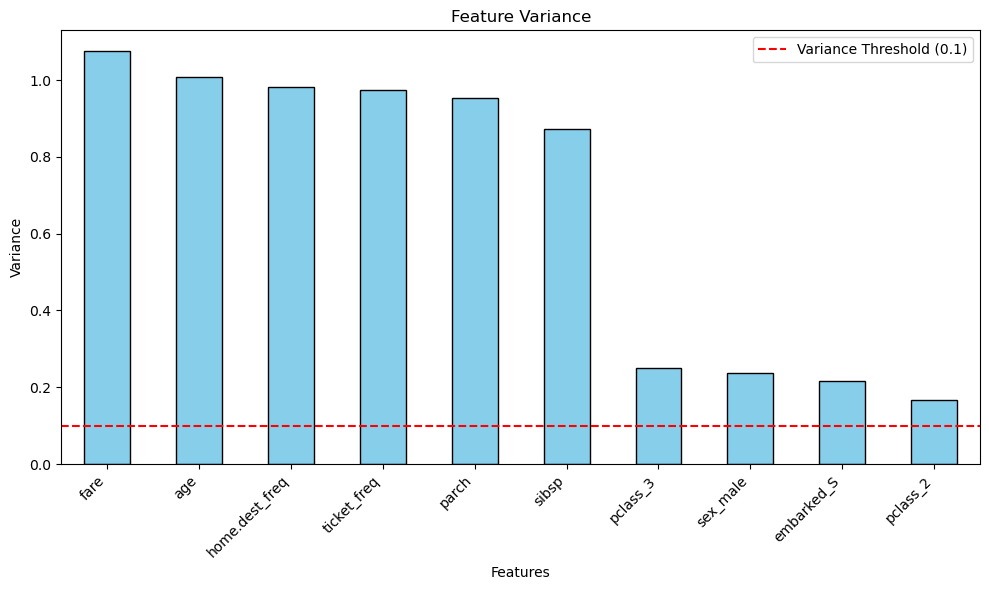

In [153]:
# Data preparation
feature_variance = pd.Series(X_final_train.var(), index=X_final_train.columns)
correlation_matrix = X_final_train.corr()

# Variance Bar Plot with Threshold Line
plt.figure(figsize=(10, 6))
feature_variance.sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='black')
plt.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5, label='Variance Threshold (0.1)')
plt.title('Feature Variance')
plt.ylabel('Variance')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

We observe that, except for the variance of `embarked_Q` (0.086), the variance of all other features is **above 0.1** (red line), indicating **relatively high variability** after standardization. 

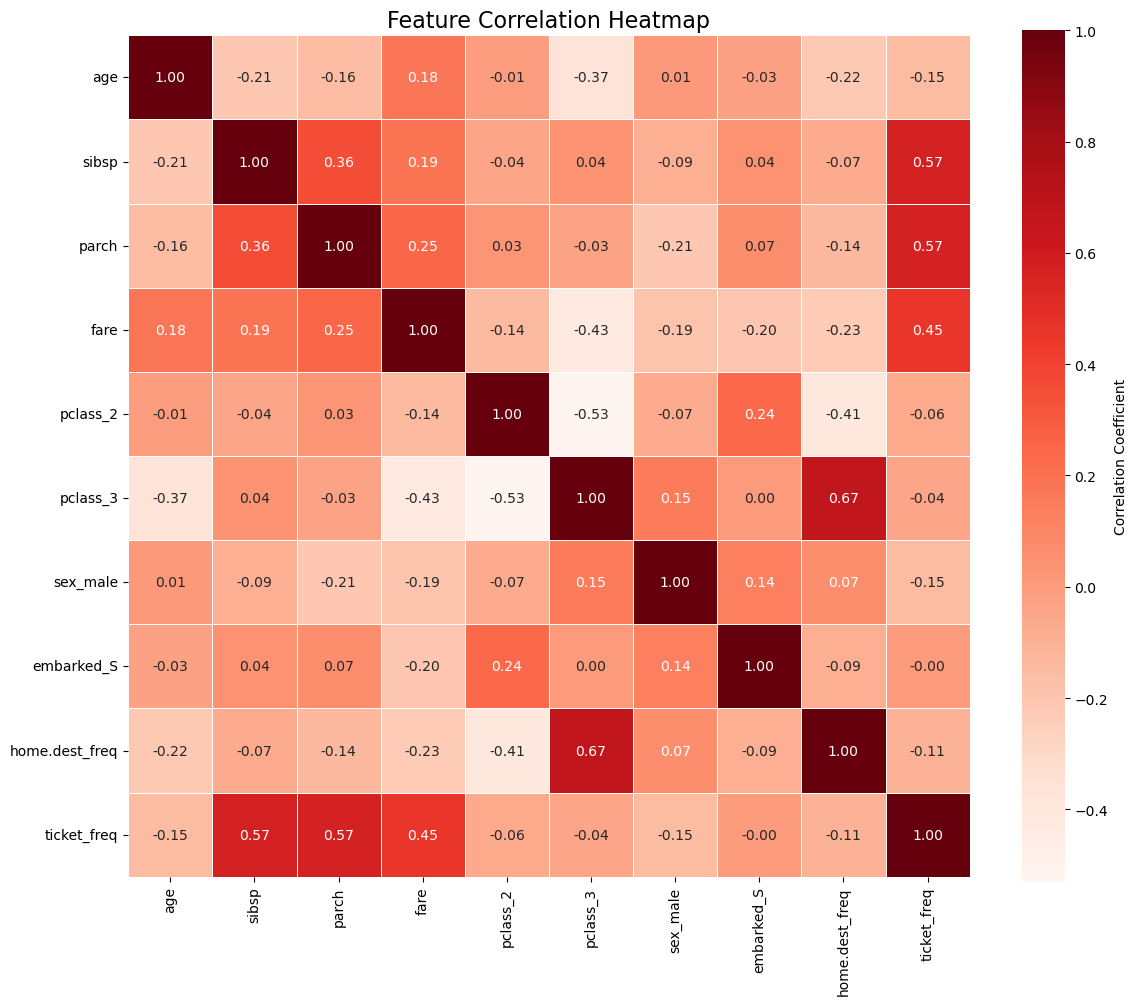

In [154]:
# Correlation Heatmap with Single-Hue Palette and Annotations
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix, 
    annot=True,  # Show correlation values
    fmt=".2f",  
    cmap='Reds',  
    cbar_kws={'label': 'Correlation Coefficient'},  
    square=True,  
    linewidths=0.5 
)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

The **correlation** of all the features is relatively **low**, with the highest absolute value of **0.67**.<br>Given that the features already exhibit sufficiently high variance and low correlation, we **proceed to the final step of model training**.

### **7.2 The Reason to Carry Out Tasks 6 and 7 After Splitting the Dataset**

We carry out **Addressing Class Imbalance** and **Feature Selection** after splitting the dataset into training, validation, and test sets is primarily to **avoid data leakage**.
- If we handle class imbalance on the **entire dataset**, the **values** of features in the training data will be obtained by examples **belonging to the holdout sets**.

- Similarly, conducting feature selection before splitting the dataset will also **incorporate the variance and correlation information** from the holdout set.<br> When the dataset is small, it might result in an **overly optimistic performance** of the model on the holdout data.

## **Task 8: Training a Logistic Regression Model**  # 

### **8.1 Logistic Regression**

In [155]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on the selected features of the training dataset
model.fit(X_final_train, y_train_resampled)

# Predict on the validation set
y_val_pred = model.predict(X_final_val)

# Evaluate the model performance
accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {accuracy:.4f}")

# Generate a classification report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.8316

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86       121
           1       0.78      0.79      0.78        75

    accuracy                           0.83       196
   macro avg       0.82      0.82      0.82       196
weighted avg       0.83      0.83      0.83       196



### **8.2 Result Interpretation**

The logistic regression model shows a validation **accuracy of 83.16%**, indicating it performs fairly well. 
- For Class 0 (Not Survived): The **precision** is 0.87, meaning that **87%** of the samples predicted as not survived are indeed not survived. The **recall** is 0.86, meaning that **86%** of all actual not survived samples are correctly identified.

- For Class 1 (Survived): The **precision** is **0.78** and **recall** is **0.79**, indicating that the model is slightly less accurate when predicting survivors, but it is able to recall 79% of the actual survivors.

- For Macro Average: The precision, recall, and F1 score are all **0.82**, indicating that the model performs **fairly balanced** across all classes.

### **8.3 Result Visualization**

#### **8.3.1 Confusion Matrix**

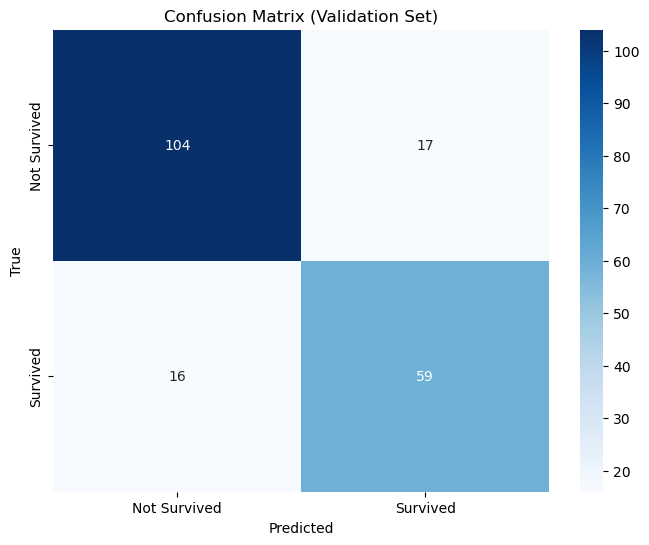

In [156]:
# Confusion Matrix for the validation set
conf_matrix_val = confusion_matrix(y_val, y_val_pred)

# Plotting Confusion Matrix for validation set
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_val, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Validation Set)')
plt.show()

#### **False Positive Rate (FPR)**  
The proportion of negative samples that are incorrectly classified as positive:
$$
\text{FPR} = \frac{17}{17 + 104} \approx 0.14 \ (14\%)
$$

#### **False Negative Rate (FNR)**  
The proportion of positive samples that are incorrectly classified as negative:
$$
\text{FNR} = \frac{16}{16 + 59} \approx 0.21 \ (21\%)
$$

#### **Key Insight:**
The **False Negative Rate (21%)** is **higher** than the **False Positive Rate (14%)**, indicating that the model is **slightly more accurate** at predicting non-survival compared to survival. 

#### **8.3.2 ROC Curve and AUC**

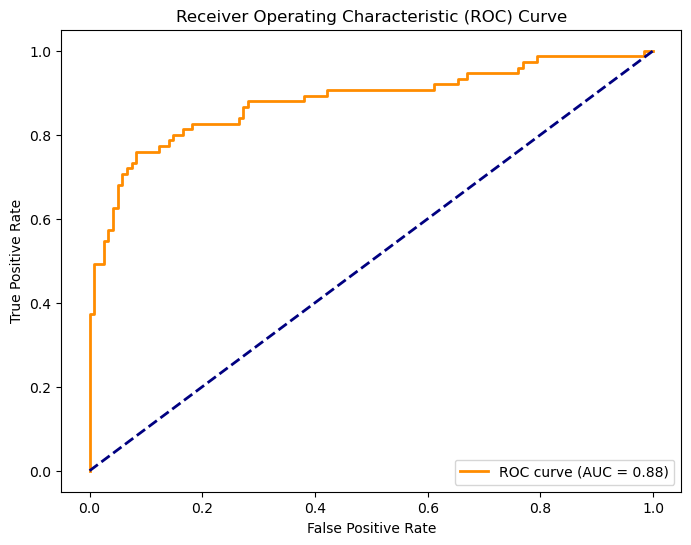

In [157]:
from sklearn.metrics import roc_curve, auc

# Get false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_val, model.predict_proba(X_final_val)[:,1])
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

- The curve is **significantly above** the diagonal baseline (dotted line).

- The **AUC of 0.88** indicates a strong discriminative ability. This means that the model has a high probability of ranking a randomly chosen positive instance (survived) higher than a randomly chosen negative instance (not survived).

#### **Key Insight:**
The model demonstrates **high predictive performance** in terms of true positive rates versus false positive rates.

#### **8.3.3 Calibration Curve**

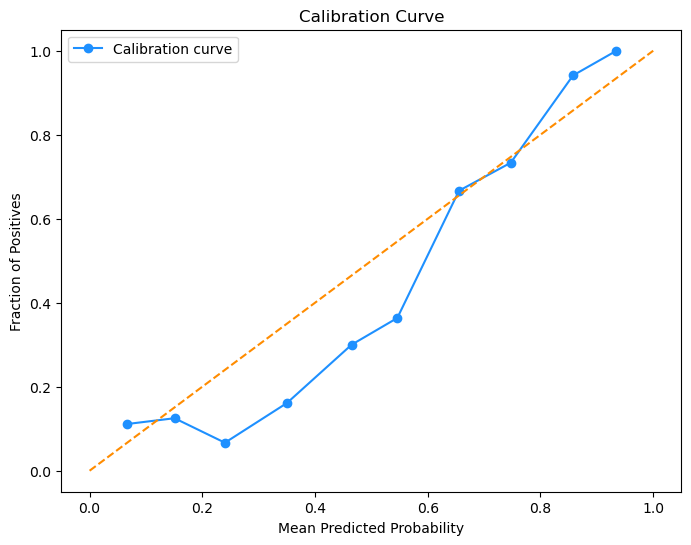

In [158]:
from sklearn.calibration import calibration_curve

# Get the true probabilities and predicted probabilities
prob_true, prob_pred = calibration_curve(y_val, model.predict_proba(X_final_val)[:,1], n_bins=10)

# Plot Calibration Curve
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', color='dodgerblue', label='Calibration curve')
plt.plot([0, 1], [0, 1], linestyle='--', color='darkorange')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.show()

- For probabilities closer to **0.6–1.0**, the predictions **align closely** with the actual outcomes.

- However, for lower predicted probabilities (0.0–0.5), the model **slightly underestimates** the fraction of positives.

#### **Key Insight:**
The model is **generally well-calibrated**, particularly for high-confidence predictions, but there is minor miscalibration at the lower probability range.